In [21]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color

In [22]:
!rm -fr sample_data
!git clone https://github.com/jmbajo/diplodatos-demo-imgs.git
!mv diplodatos-demo-imgs/* .
!rm -rf diplodatos-demo-imgs

Cloning into 'diplodatos-demo-imgs'...
remote: Enumerating objects: 19, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 19 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (19/19), 6.27 MiB | 10.68 MiB/s, done.
Resolving deltas: 100% (3/3), done.


In [23]:
# Cargar la imagen
imagen = io.imread('cameraman.jpg')

# Aplicar la FFT
fft_imagen = np.fft.fft2(imagen)
fft_imagen_shifted = np.fft.fftshift(fft_imagen)

print(fft_imagen_shifted.shape)
print(fft_imagen_shifted.dtype)

# Obtener la magnitud
magnitud = np.abs(fft_imagen_shifted)
magnitud_log = np.log(1 + magnitud)  # Log para visualizar mejor

(256, 256)
complex128


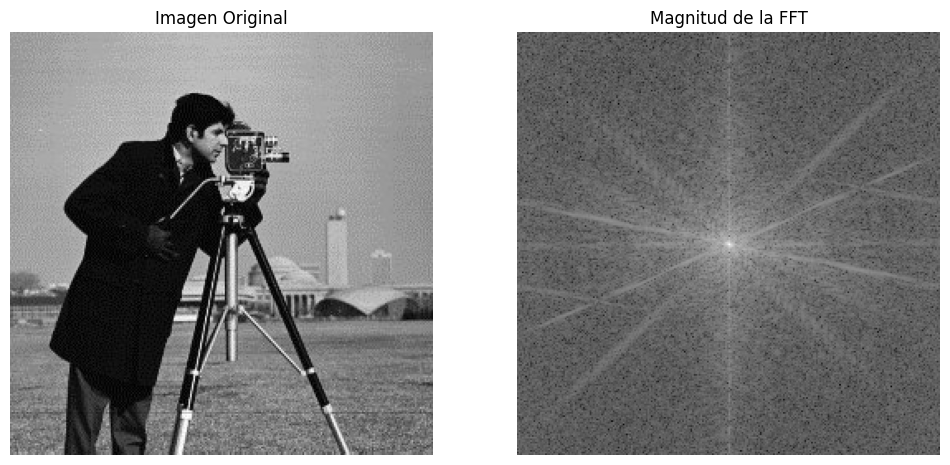

In [24]:
# Mostrar la imagen original y la magnitud de la FFT
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title('Imagen Original')
plt.imshow(imagen, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Magnitud de la FFT')
plt.imshow(magnitud_log, cmap='gray')
plt.axis('off')

plt.show()

(256, 256)
0 1
0 1


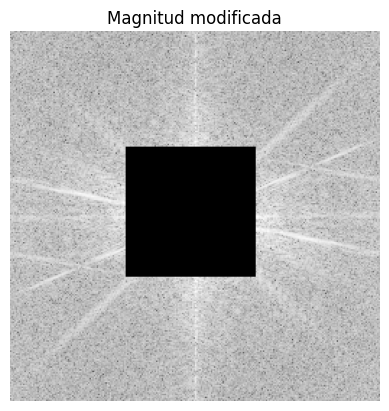

In [32]:
mascara = np.ones(fft_imagen_shifted.shape, dtype="uint8")
print(mascara.shape)

mascara[80:170, 80:170] = 0
print(np.min(mascara),np.max(mascara))

# mascara = 1 - mascara

print(np.min(mascara),np.max(mascara))

fft_imagen_shifted = fft_imagen_shifted * mascara
magnitud = np.abs(fft_imagen_shifted)
magnitud_log = np.log(1 + magnitud)

plt.title('Magnitud modificada')
plt.imshow(magnitud_log, cmap='gray')
plt.axis('off')

plt.show()



In [33]:
# Aplicar la IFFT
imagen_reconstruida = np.fft.ifft2(np.fft.ifftshift(fft_imagen_shifted)).real

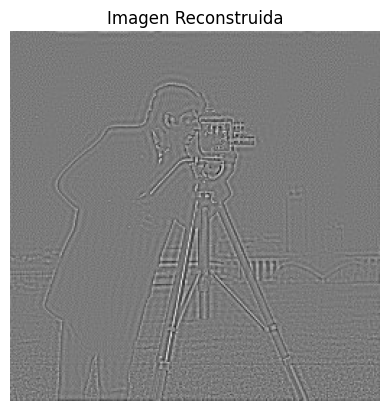

In [34]:
plt.title('Imagen Reconstruida')
plt.imshow(imagen_reconstruida, cmap='gray')
plt.axis('off')

plt.show()